## Eps 8

In [92]:
import pandas as pd
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/Narcissus/PoisonedGen.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

global_filters = {'noise_eps_narcissus': 16, 
                  }

# Global filters
for key, value in global_filters.items():
    df = df[df[key] == value]

df_results = []
for data_key in df['Data Key'].unique():
    df_filt = df[df['Data Key'] == data_key]

    # Extract the defense name
    label = data_key.split('[')[0]

    # Get Steps
    if label in ['DM_UNET']:
        continue
        steps = int(data_key.split('_T[')[1].split(']')[0])
        label += f"-{steps}"
    else:
        steps = int(data_key.split('Steps[')[1].split(']')[0])
        label += f"-{steps}"

    # Get Eps
    try:
        eps = data_key.split('eps=')[1].split(']')[0]
    except:
        eps = 0

    df_results.append({'Defense': label,
                       'Eps': int(eps),
                       'Steps': steps,
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean():.2%}\u00B1{df_filt['End Acc'].std():.2%}",
                        'Poison Success': df_filt['P1 Acc'].mean(),
                        'Poison Success Str': f"{df_filt['P1 Acc'].mean():.2%}\u00B1{df_filt['P1 Acc'].std():.2%}",
                        'Max Poison Success': df_filt['P1 Acc'].max(),
                        'Max Poison Success Str': f"{df_filt['P1 Acc'].max():.2%}",
                        'Num Results': len(df_filt),
                    })

df_results = pd.DataFrame(df_results)
df_results.sort_values(by=['Defense','Eps'], inplace=True)
df_results

,Defense,Eps,Steps,Nat Acc,Nat Acc Str,Poison Success,Poison Success Str,Max Poison Success,Max Poison Success Str,Num Results
4,EBM-1000,8,1000,0.85171,85.17%±0.24%,0.048398,4.84%±2.46%,0.079159,7.92%,10
9,EBM-1000,16,1000,0.85609,85.61%±0.14%,0.136615,13.66%±18.55%,0.649934,64.99%,10
3,EBM-2000,8,2000,0.81905,81.91%±0.25%,0.046626,4.66%±2.59%,0.090889,9.09%,10
6,EBM-2000,16,2000,0.82457,82.46%±0.28%,0.145136,14.51%±22.19%,0.761664,76.17%,10
5,EBM-750,8,750,0.86235,86.23%±0.14%,0.048904,4.89%±2.57%,0.089107,8.91%,10
12,EBM-750,16,750,0.86559,86.56%±0.14%,0.168721,16.87%±22.93%,0.798702,79.87%,10
1,EBMSNGAN32-1000,0,1000,0.87742,87.74%±0.32%,0.082258,8.23%±4.64%,0.148812,14.88%,10
10,EBMSNGAN32-1000,8,1000,0.87184,87.18%±0.33%,0.055922,5.59%±3.29%,0.114789,11.48%,10
11,EBMSNGAN32-1000,16,1000,0.85057,85.06%±0.37%,0.264718,26.47%±25.08%,0.756844,75.68%,10
0,EBMSNGAN32-2000,0,2000,0.85458,85.46%±0.14%,0.070480,7.05%±3.55%,0.119630,11.96%,10


Text(0, 0.5, 'Natural Accuracy')

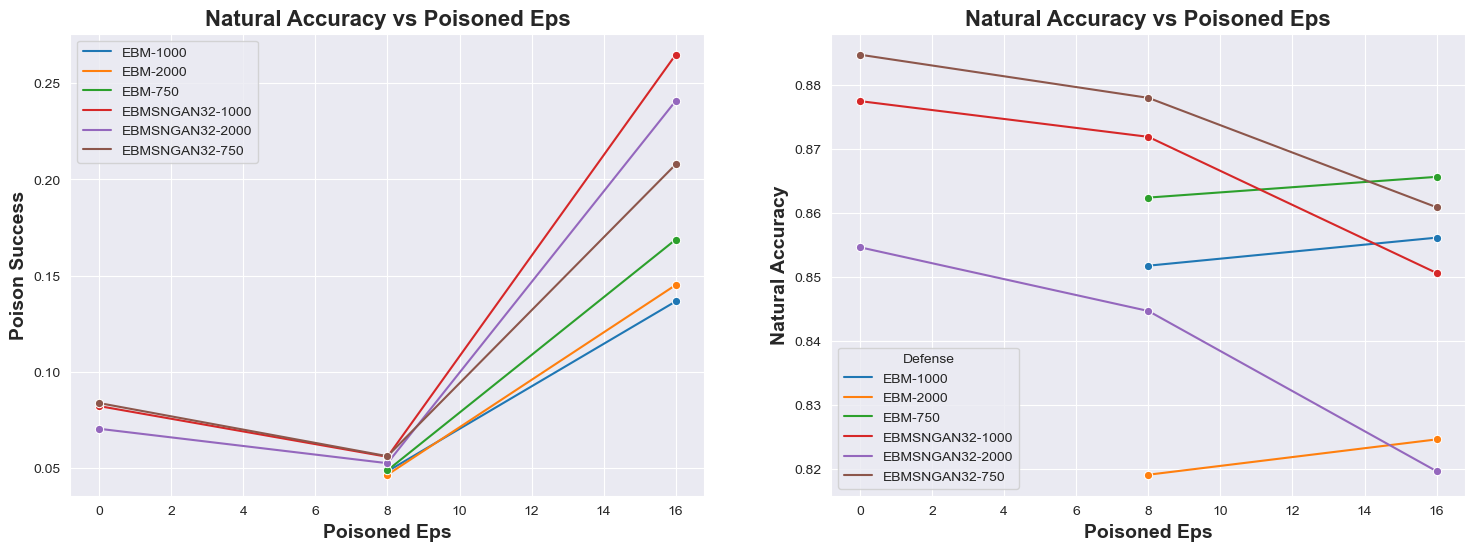

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Poison Defense
sns.lineplot(data=df_results, x='Eps', y='Poison Success', hue='Defense', marker='o',palette='tab10', ax=axs[0])
axs[0].set_title('Natural Accuracy vs Poisoned Eps',fontsize=16, fontweight='bold')
axs[0].set_xlabel('Poisoned Eps', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Poison Success', fontsize=14, fontweight='bold')
axs[0].legend()

# Natural Accuracy
sns.lineplot(data=df_results, x='Eps', y='Nat Acc', hue='Defense', marker='o',palette='tab10', ax=axs[1])
axs[1].set_title('Natural Accuracy vs Poisoned Eps',fontsize=16, fontweight='bold')
axs[1].set_xlabel('Poisoned Eps', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Natural Accuracy', fontsize=14, fontweight='bold')

# plt.savefig('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense.pdf', dpi=300,bbox_inches='tight')

In [44]:
dm_plot_diff

,Defense,Eps,Nat Acc,Nat Acc Str,Poison Success,Poison Success Str,Max Poison Success,Max Poison Success Str,Num Results,Label,Steps
0,EBMSNGAN32-2000,0,0.85458,85.46%±0.14%,0.070480,7.05%±3.55%,0.119630,11.96%,10,EBMSNGAN32,2000
1,EBMSNGAN32-1000,0,0.87742,87.74%±0.32%,0.082258,8.23%±4.64%,0.148812,14.88%,10,EBMSNGAN32,1000
2,EBMSNGAN32-750,0,0.88467,88.47%±0.22%,0.083831,8.38%±5.28%,0.185673,18.57%,10,EBMSNGAN32,750
3,DM_UNET-150,0,0.84863,84.86%±0.18%,0.053308,5.33%±2.98%,0.113116,11.31%,10,DM_UNET,150
4,DM_UNET-125,0,0.86376,86.38%±0.11%,0.064890,6.49%±4.24%,0.140031,14.00%,10,DM_UNET,125
5,DM_UNET-100,0,0.87962,87.96%±0.17%,0.067989,6.80%±4.32%,0.139085,13.91%,10,DM_UNET,100
6,DM_UNET-75,0,0.89464,89.46%±0.19%,0.085271,8.53%±6.57%,0.210915,21.09%,10,DM_UNET,75
7,DM_UNET-150,8,0.83538,83.54%±0.16%,0.052346,5.23%±3.28%,0.108275,10.83%,10,DM_UNET,150
8,DM_UNET-125,8,0.85319,85.32%±0.22%,0.047755,4.78%±2.86%,0.097997,9.80%,10,DM_UNET,125
9,DM_UNET-100,8,0.87039,87.04%±0.31%,0.054934,5.49%±3.30%,0.104137,10.41%,10,DM_UNET,100
